# Tutorials for BAO predictions
The `BAO_alphas` class in `summary_statistics.bao_alphas` contains methods to compute $\alpha_{\parallel}$, $\alpha_{\perp}$, $\alpha_{\rm iso}$, $\alpha_{\rm AP}$ given a set of cosmological parameters, a fiducial cosmology (both from a `Background` object) and a set of redshifts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.summary_statistics.bao_alphas import BaryonAcousticOscillations

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

### Define background cosmology and fiducial background and create instances of CAMBBackground for both

In [2]:
H0_fid = 67.7
Omega_cdm0_fid = 0.27
Omega_b0 = 0.049
Omega_k0 = 0.0
w0 = -1.0
wa = 0.0
ns = 0.96
As = 2.1e-9
gamma_MG = 0.545
mnu = 0.0
N_mnu = 0

background_fiducial = CAMBBackground(
    H0=H0_fid, Omega_cdm0=Omega_cdm0_fid, Omega_b0=Omega_b0, Omega_k0=Omega_k0,
    w0=w0, wa=wa, ns=ns, As=As, gamma_MG=gamma_MG, mnu=mnu, N_mnu=N_mnu
)

Omega_cdm0 = 0.28
H0 = 70.0

background = CAMBBackground(
    H0=H0, Omega_cdm0=Omega_cdm0, Omega_b0=Omega_b0, Omega_k0=Omega_k0,
    w0=w0, wa=wa, ns=ns, As=As, gamma_MG=gamma_MG, mnu=mnu, N_mnu=N_mnu
)

Then create a list of redshifts and an instance of `BAO_alphas`: 

In [3]:
# Choose redshift
zs = [1., 1.2, 1.4, 1.65]

# Create instance of BAO_alphas
bao = BaryonAcousticOscillations(background, background_fiducial, zs)

The values for $\alpha_{\parallel}$, $\alpha_{\perp}$, $\alpha_{\rm iso}$ and $\alpha_{\rm AP}$ for the requested redshifts are contained in the `alphas_dict` attribute of the class:

In [4]:
bao.alphas_dict

{1.0: {'alpha_par': np.float64(0.9902517856403517),
  'alpha_perp': np.float64(0.9952202078106681),
  'alpha_iso': np.float64(0.9935613034429395),
  'alpha_AP': np.float64(0.9950077157484108)},
 1.2: {'alpha_par': np.float64(0.9892835013388309),
  'alpha_perp': np.float64(0.9945591951741053),
  'alpha_iso': np.float64(0.9927975118987926),
  'alpha_AP': np.float64(0.9946954451169185)},
 1.4: {'alpha_par': np.float64(0.9885486304344844),
  'alpha_perp': np.float64(0.9940084064298845),
  'alpha_iso': np.float64(0.9921851388000874),
  'alpha_AP': np.float64(0.9945073140628562)},
 1.65: {'alpha_par': np.float64(0.987868736737357),
  'alpha_perp': np.float64(0.9934424890480026),
  'alpha_iso': np.float64(0.9915810860978865),
  'alpha_AP': np.float64(0.9943894564888333)}}

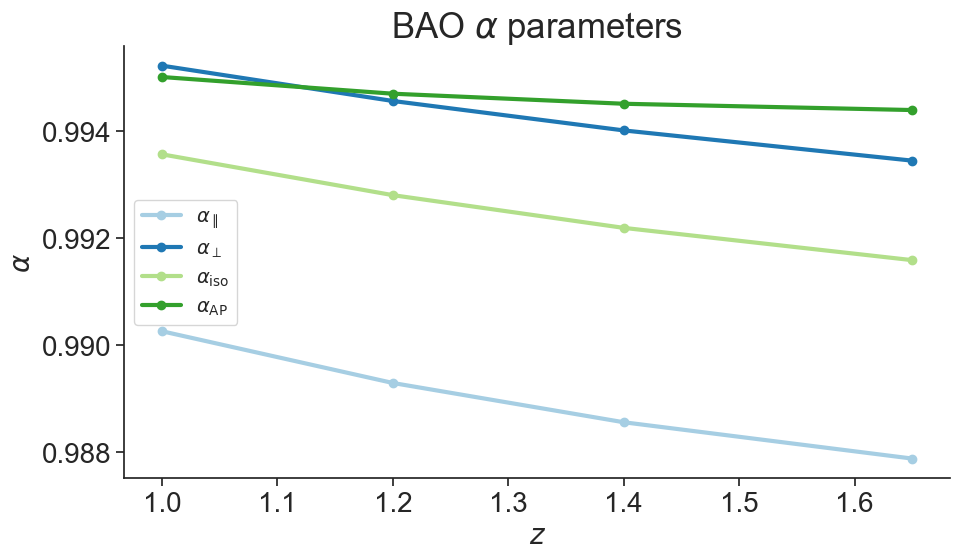

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

# Reorganize: for each alpha type, collect values across redshifts
alpha_keys = bao.alphas_dict[zs[0]].keys()

for alpha_key in alpha_keys:
    alpha_values = [bao.alphas_dict[z][alpha_key] for z in zs]
    latex_label = {
        "alpha_par": r"$\alpha_{\parallel}$",
        "alpha_perp": r"$\alpha_{\perp}$",
        "alpha_iso": r"$\alpha_{\rm iso}$",
        "alpha_AP": r"$\alpha_{\rm AP}$",
    }.get(alpha_key, rf"$\mathrm{{{alpha_key}}}$")
    ax.plot(zs, alpha_values, marker='o', label=latex_label)

ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$\alpha$')
ax.set_title(r'BAO $\alpha$ parameters')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()